<h1>Leaf Disease Classification - Keras CNN .. With 96% Accuracy</h1>
<img 
style="width : 100%;margin: auto;"    
src="https://www.google.com/search?q=leaf+disease&sxsrf=ALiCzsb-Fr5LvT82eoxXJt3fDQmP8Qo_cA:1654161628719&source=lnms&tbm=isch&sa=X&ved=2ahUKEwiGpZ-iuI74AhVKBaYKHYEJBIMQ_AUoAXoECAIQAw&biw=1707&bih=806&dpr=1.13#imgrc=BJHS-ZYd7zmuTM&imgdii=O8NuCBPDZa8ipM>

In [ ]:
import os

print(os.listdir("/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"))



In [8]:
model.save("/kaggle/working/cnn_model.h5")
print("Saved successfully")


Saved successfully


In [6]:
from IPython.display import FileLink

FileLink("/kaggle/working/cnn_model.h5")


/kaggle/working/cnn_model.h5

In [4]:
import os
print(os.listdir("/kaggle/working"))


['.virtual_documents', 'cnn_model.h5']


In [ ]:
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
import matplotlib.pyplot as plt
tf.random.set_seed(0)
from tensorflow import keras
import numpy as np
np.random.seed(0)
import itertools
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Rescaling
from sklearn.metrics import precision_score, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

<h1>Data Loading</h1>
<p>Setting up Image Data Generators<p>

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Rescaling

# Base path
base_path = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

# Load training data
train_gen = image_dataset_from_directory(
    directory=base_path + "/train",
    image_size=(256, 256)
)

# Load validation data
test_gen = image_dataset_from_directory(
    directory=base_path + "/valid",
    image_size=(256, 256)
)

# Rescaling
rescale = Rescaling(1.0/255)

train_gen = train_gen.map(lambda image, label: (rescale(image), label))
test_gen  = test_gen.map(lambda image, label: (rescale(image), label))



<h1>Data Engineering</h1>
<p>Since the data is already augmented, there is no requirement of data engineering. Feature scaling is automatically done by image generators</p>

<h1>Modelling</h1>

In [ ]:
model = keras.Sequential()

# Block 1
model.add(keras.layers.Conv2D(32,(3,3),activation="relu",padding="same",input_shape=(256,256,3)))
model.add(keras.layers.Conv2D(32,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(2,2))

# Block 2
model.add(keras.layers.Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(2,2))

# Block 3
model.add(keras.layers.Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(2,2))

# Block 4
model.add(keras.layers.Conv2D(256,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(256,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(2,2))

# Dense layers
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(512,activation="relu"))
model.add(keras.layers.Dropout(0.5))

# Output layer
model.add(keras.layers.Dense(38,activation="softmax"))

# Compile
opt = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt,
              loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])

model.summary()


In [ ]:
ep = 10

history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=ep
)


In [1]:
from tensorflow.keras.models import load_model

model = load_model("cnn_model.h5")


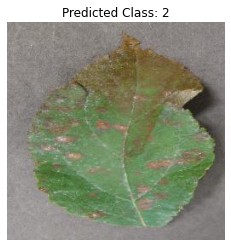

In [3]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# 1. Load model
model = load_model("cnn_model.h5")

# 2. Image path
img_path = "/kaggle/input/new-plant-diseases-dataset/test/test/AppleCedarRust4.JPG"

# 3. Load image
img = image.load_img(img_path, target_size=(256,256))

# 4. Convert image
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# 5. Predict
pred = model.predict(img_array)
pred_class = np.argmax(pred)

# 6. Show image + result
plt.imshow(img)
plt.title(f"Predicted Class: {pred_class}")
plt.axis("off")
plt.show()



In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

model = load_model("cnn_model.h5")

img = image.load_img("test.jpg", target_size=(256,256))
img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)

pred = model.predict(img)
print(np.argmax(pred))


In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))


<h1>Metrics</h1>

In [ ]:
labels = []
predictions = []

for x, y in test_gen:
    preds = model.predict(x, verbose=0)
    
    labels.extend(y.numpy())
    predictions.extend(tf.argmax(preds, axis=1).numpy())

In [ ]:
predictions = list(itertools.chain.from_iterable(predictions))
labels = list(itertools.chain.from_iterable(labels))

In [ ]:
print("Train Accuracy  : {:.2f} %".format(history.history['accuracy'][-1]*100))
print("Test Accuracy   : {:.2f} %".format(accuracy_score(labels, predictions) * 100))
print("Precision Score : {:.2f} %".format(precision_score(labels, predictions, average='micro') * 100))
print("Recall Score    : {:.2f} %".format(recall_score(labels, predictions, average='micro') * 100))

<h3>Confusion Matrix</h3>

In [ ]:
plt.figure(figsize= (20,5))
cm = confusion_matrix(labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(range(1,39)))
fig, ax = plt.subplots(figsize=(15,15))
disp.plot(ax=ax,colorbar= False,cmap = 'YlGnBu')
plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()